<a href="https://colab.research.google.com/github/thuyntp26/LinearRegression/blob/main/hoiquy_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LOAD DỮ LIỆU VÀ KIỂM TRA DỮ LIỆU**

In [16]:
import pandas as pd
import csv

# Đọc dữ liệu từ URL raw
df = pd.read_csv("https://raw.githubusercontent.com/thuyntp26/LinearRegression/refs/heads/main/StudentPerformanceFactors.csv")

print("Shape:", df.shape)
df.head()

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [17]:
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Column names:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Data types:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities    

In [18]:
# =========================
# COLUMN GROUPING
# =========================
target_col = "Exam_Score"

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print("Target column:", target_col)
print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Target column: Exam_Score

Numeric columns:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [19]:
# =========================
# MISSING VALUE SUMMARY
# =========================
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ["Feature", "Missing_Count"]
missing_df["Missing_Percentage"] = (missing_df["Missing_Count"] / len(df)) * 100
missing_df = missing_df[missing_df["Missing_Count"] > 0].sort_values(by="Missing_Count", ascending=False)

missing_df

,Feature,Missing_Count,Missing_Percentage
16,Parental_Education_Level,90,1.362192
11,Teacher_Quality,78,1.180566
17,Distance_from_Home,67,1.014076


count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


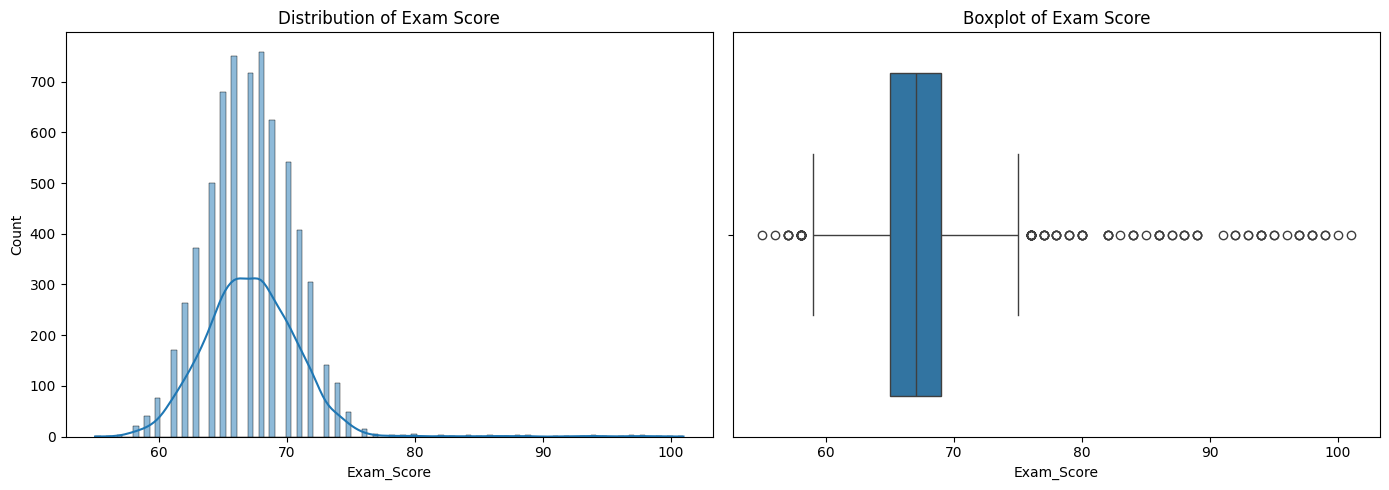

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# TARGET VARIABLE ANALYSIS
# =========================
print(df[target_col].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[target_col], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Exam Score")

sns.boxplot(x=df[target_col], ax=axes[1])
axes[1].set_title("Boxplot of Exam Score")

plt.tight_layout()
plt.show()

--> Nhận định: Phân bố điểm số gần như chuẩn, tập trung quanh mức ~67. Hầu hết học sinh nằm trong phạm vi điểm số hẹp (65–69). Một vài điểm số ngoại lệ cao (>90) đại diện cho những học sinh đạt điểm cao nhất. Kết quả học tập của học sinh tập trung khá chặt chẽ, cho thấy sự biến động hạn chế.

**TIỀN XỬ LÝ DỮ LIỆU**